In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the E-commerce dataset
ecom_path = r"C:\SQL PROJECTS\DATALAB_INTERN\onlineretail.csv"

try:
    ecom_df = pd.read_csv(ecom_path, encoding='latin-1')
    print("✅ E-commerce dataset loaded successfully!")
    
    # Display first few rows
    print("\n" + "="*50)
    print("FIRST 5 ROWS OF E-COMMERCE DATASET")
    print("="*50)
    print(ecom_df.head())
    
    # Display last few rows
    print("\n" + "="*50)
    print("LAST 5 ROWS OF E-COMMERCE DATASET")
    print("="*50)
    print(ecom_df.tail())
    
except FileNotFoundError:
    print("❌ File not found. Please check the file path.")
    print("   Current path:", ecom_path)

✅ E-commerce dataset loaded successfully!

FIRST 5 ROWS OF E-COMMERCE DATASET
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

LAST 5 ROWS OF E-COMMERCE DATASET
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613 

In [4]:
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)

# 1. Dataset shape
print(f"\n📊 Number of rows: {ecom_df.shape[0]:,}")
print(f"📊 Number of columns: {ecom_df.shape[1]}")

# 2. Data types of all columns
print("\n" + "-"*50)
print("DATA TYPES:")
print("-"*50)
print(ecom_df.dtypes)

# 3. Identify numerical and categorical features
print("\n" + "-"*50)
print("FEATURE TYPES:")
print("-"*50)

numerical_features = ecom_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = ecom_df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 Numerical features ({len(numerical_features)}):")
for feat in numerical_features:
    print(f"   - {feat}")

print(f"\n📋 Categorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"   - {feat}")

# 4. Check for unique identifiers
print("\n" + "-"*50)
print("UNIQUE IDENTIFIERS:")
print("-"*50)
print(f"StockCode unique count: {ecom_df['StockCode'].nunique():,}")
print(f"InvoiceNo unique count: {ecom_df['InvoiceNo'].nunique():,}")
print(f"CustomerID unique count: {ecom_df['CustomerID'].nunique():,}")

# 5. Dataset description
print("\n" + "-"*50)
print("DATASET DESCRIPTION:")
print("-"*50)
print("\nThis dataset contains transactional data from an online retail store.")
print("It includes details such as:")
print("- Invoice number and date")
print("- Customer ID")
print("- Product details (StockCode, Description)")
print("- Quantity purchased")
print("- Unit price")
print("- Country of customer")
print("- Total transaction value (Quantity × UnitPrice)")

# 6. Summary statistics
print("\n" + "-"*50)
print("SUMMARY STATISTICS (NUMERICAL FEATURES):")
print("-"*50)
print(ecom_df[numerical_features].describe())


DATASET INFORMATION

📊 Number of rows: 541,909
📊 Number of columns: 8

--------------------------------------------------
DATA TYPES:
--------------------------------------------------
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

--------------------------------------------------
FEATURE TYPES:
--------------------------------------------------

📈 Numerical features (3):
   - Quantity
   - UnitPrice
   - CustomerID

📋 Categorical features (5):
   - InvoiceNo
   - StockCode
   - Description
   - InvoiceDate
   - Country

--------------------------------------------------
UNIQUE IDENTIFIERS:
--------------------------------------------------
StockCode unique count: 4,070
InvoiceNo unique count: 25,900
CustomerID unique count: 4,372

--------------------------------------------------
DATASET DESCRIPTION:
--------------------------------

In [5]:
print("\n" + "="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

# Count missing values per column
missing_values = ecom_df.isnull().sum()
missing_percentage = (ecom_df.isnull().sum() / len(ecom_df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage.round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("\n📊 Columns with missing values:")
print(missing_summary)

# Show total missing values
print(f"\n📊 Total missing values: {ecom_df.isnull().sum().sum():,}")


MISSING VALUES ANALYSIS

📊 Columns with missing values:
             Missing Count  Missing Percentage
CustomerID          135080               24.93
Description           1454                0.27

📊 Total missing values: 136,534


In [7]:
print("="*50)
print("HANDLING MISSING VALUES - E-COMMERCE DATASET")
print("="*50)

# Create a copy for cleaning
ecom_clean = ecom_df.copy()

print("\n1. BEFORE HANDLING MISSING VALUES:")
print("-"*50)
print(f"Missing in CustomerID: {ecom_clean['CustomerID'].isnull().sum():,}")
print(f"Missing in Description: {ecom_clean['Description'].isnull().sum():,}")

# Handle missing CustomerID - these are transactions without customer info
# Option 1: Remove rows with missing CustomerID (since we need customer-level analysis)
print("\n2. HANDLING MISSING CUSTOMERID:")
print("-"*50)

# Remove rows with missing CustomerID
ecom_clean = ecom_clean.dropna(subset=['CustomerID'])
print(f"✓ Removed {135080:,} rows with missing CustomerID")  # Fixed: removed commas in number
print(f"   New dataset shape: {ecom_clean.shape}")

# Handle missing Description
print("\n3. HANDLING MISSING DESCRIPTION:")
print("-"*50)
# Fill missing descriptions with 'Unknown'
ecom_clean['Description'] = ecom_clean['Description'].fillna('Unknown')
print(f"✓ Filled {1454} missing Description values with 'Unknown'")  # Fixed: removed commas or use {1454:,}

# Verify missing values are handled
print("\n4. AFTER HANDLING MISSING VALUES:")
print("-"*50)
print(f"Missing in CustomerID: {ecom_clean['CustomerID'].isnull().sum()}")
print(f"Missing in Description: {ecom_clean['Description'].isnull().sum()}")

# Show final dataset shape
print(f"\nFinal dataset shape: {ecom_clean.shape}")
print(f"Rows removed: {len(ecom_df) - len(ecom_clean):,}")

HANDLING MISSING VALUES - E-COMMERCE DATASET

1. BEFORE HANDLING MISSING VALUES:
--------------------------------------------------
Missing in CustomerID: 135,080
Missing in Description: 1,454

2. HANDLING MISSING CUSTOMERID:
--------------------------------------------------
✓ Removed 135,080 rows with missing CustomerID
   New dataset shape: (406829, 8)

3. HANDLING MISSING DESCRIPTION:
--------------------------------------------------
✓ Filled 1454 missing Description values with 'Unknown'

4. AFTER HANDLING MISSING VALUES:
--------------------------------------------------
Missing in CustomerID: 0
Missing in Description: 0

Final dataset shape: (406829, 8)
Rows removed: 135,080


In [8]:
print("\n" + "="*50)
print("DATA QUALITY CHECKS")
print("="*50)

# 1. Check for negative quantities (returns/refunds)
print("\n1. CHECKING FOR NEGATIVE QUANTITIES:")
print("-"*50)
negative_qty = ecom_clean[ecom_clean['Quantity'] < 0]
print(f"   Rows with negative Quantity: {len(negative_qty):,}")
print(f"   Percentage: {len(negative_qty)/len(ecom_clean)*100:.2f}%")

# 2. Check for negative unit prices (returns)
print("\n2. CHECKING FOR NEGATIVE UNIT PRICES:")
print("-"*50)
negative_price = ecom_clean[ecom_clean['UnitPrice'] < 0]
print(f"   Rows with negative UnitPrice: {len(negative_price):,}")
print(f"   Percentage: {len(negative_price)/len(ecom_clean)*100:.2f}%")

# 3. Check for zero or near-zero quantities
print("\n3. CHECKING FOR ZERO QUANTITIES:")
print("-"*50)
zero_qty = ecom_clean[ecom_clean['Quantity'] == 0]
print(f"   Rows with Quantity = 0: {len(zero_qty):,}")

# 4. Check for extremely high values
print("\n4. CHECKING FOR OUTLIERS:")
print("-"*50)
high_quantity = ecom_clean[ecom_clean['Quantity'] > 1000]
print(f"   Rows with Quantity > 1000: {len(high_quantity):,}")
high_price = ecom_clean[ecom_clean['UnitPrice'] > 1000]
print(f"   Rows with UnitPrice > 1000: {len(high_price):,}")

# 5. Check for invalid stock codes
print("\n5. CHECKING FOR INVALID STOCKCODES:")
print("-"*50)
# StockCode should not start with 'A' (adjustment codes)
invalid_stock = ecom_clean[ecom_clean['StockCode'].astype(str).str.startswith('A', na=False)]
print(f"   Rows with StockCode starting with 'A' (adjustment): {len(invalid_stock):,}")


DATA QUALITY CHECKS

1. CHECKING FOR NEGATIVE QUANTITIES:
--------------------------------------------------
   Rows with negative Quantity: 8,905
   Percentage: 2.19%

2. CHECKING FOR NEGATIVE UNIT PRICES:
--------------------------------------------------
   Rows with negative UnitPrice: 0
   Percentage: 0.00%

3. CHECKING FOR ZERO QUANTITIES:
--------------------------------------------------
   Rows with Quantity = 0: 0

4. CHECKING FOR OUTLIERS:
--------------------------------------------------
   Rows with Quantity > 1000: 106
   Rows with UnitPrice > 1000: 46

5. CHECKING FOR INVALID STOCKCODES:
--------------------------------------------------
   Rows with StockCode starting with 'A' (adjustment): 0


In [9]:
print("\n" + "="*50)
print("REMOVING INVALID RECORDS & DUPLICATES")
print("="*50)

# Store initial row count
initial_rows = len(ecom_clean)
print(f"Initial rows: {initial_rows:,}")

# 1. Remove rows with negative Quantity (returns)
ecom_clean = ecom_clean[ecom_clean['Quantity'] > 0]
print(f"\n1. Removed negative Quantity rows")
print(f"   Rows remaining: {len(ecom_clean):,}")
print(f"   Removed: {initial_rows - len(ecom_clean):,} rows")

# 2. Remove rows with negative UnitPrice
ecom_clean = ecom_clean[ecom_clean['UnitPrice'] > 0]
print(f"\n2. Removed negative UnitPrice rows")
print(f"   Rows remaining: {len(ecom_clean):,}")
print(f"   Removed: {initial_rows - len(ecom_clean):,} total rows")

# 3. Remove rows with StockCode starting with 'A' (adjustments)
ecom_clean = ecom_clean[~ecom_clean['StockCode'].astype(str).str.startswith('A', na=False)]
print(f"\n3. Removed adjustment StockCode rows")
print(f"   Rows remaining: {len(ecom_clean):,}")

# 4. Remove duplicates
duplicates_before = ecom_clean.duplicated().sum()
ecom_clean = ecom_clean.drop_duplicates()
print(f"\n4. Removed duplicate rows")
print(f"   Duplicates removed: {duplicates_before:,}")
print(f"   Rows remaining: {len(ecom_clean):,}")

# Final summary
print("\n" + "-"*50)
print("CLEANING SUMMARY:")
print("-"*50)
print(f"Initial rows: {initial_rows:,}")
print(f"Final rows: {len(ecom_clean):,}")
print(f"Total rows removed: {initial_rows - len(ecom_clean):,}")
print(f"Percentage removed: {(initial_rows - len(ecom_clean))/initial_rows*100:.2f}%")


REMOVING INVALID RECORDS & DUPLICATES
Initial rows: 406,829

1. Removed negative Quantity rows
   Rows remaining: 397,924
   Removed: 8,905 rows

2. Removed negative UnitPrice rows
   Rows remaining: 397,884
   Removed: 8,945 total rows

3. Removed adjustment StockCode rows
   Rows remaining: 397,884

4. Removed duplicate rows
   Duplicates removed: 5,192
   Rows remaining: 392,692

--------------------------------------------------
CLEANING SUMMARY:
--------------------------------------------------
Initial rows: 406,829
Final rows: 392,692
Total rows removed: 14,137
Percentage removed: 3.47%


In [10]:
print("\n" + "="*50)
print("STANDARDIZATION")
print("="*50)

# 1. Convert InvoiceDate to datetime
print("\n1. Converting InvoiceDate to datetime...")
ecom_clean['InvoiceDate'] = pd.to_datetime(ecom_clean['InvoiceDate'])
print(f"   ✓ Successfully converted to datetime")
print(f"   Date range: {ecom_clean['InvoiceDate'].min()} to {ecom_clean['InvoiceDate'].max()}")

# 2. Extract date components
ecom_clean['InvoiceYear'] = ecom_clean['InvoiceDate'].dt.year
ecom_clean['InvoiceMonth'] = ecom_clean['InvoiceDate'].dt.month
ecom_clean['InvoiceDay'] = ecom_clean['InvoiceDate'].dt.day
ecom_clean['InvoiceHour'] = ecom_clean['InvoiceDate'].dt.hour
print(f"   ✓ Extracted year, month, day, hour from InvoiceDate")

# 3. Standardize text columns
print("\n2. Standardizing text columns...")
ecom_clean['Description'] = ecom_clean['Description'].str.strip().str.upper()
ecom_clean['Country'] = ecom_clean['Country'].str.strip().str.upper()
print(f"   ✓ Standardized 'Description' and 'Country' to uppercase")

# 4. Calculate Total Amount (Revenue)
print("\n3. Creating calculated columns...")
ecom_clean['TotalAmount'] = ecom_clean['Quantity'] * ecom_clean['UnitPrice']
print(f"   ✓ Created 'TotalAmount' column (Quantity × UnitPrice)")
print(f"   Total revenue: ${ecom_clean['TotalAmount'].sum():,.2f}")

print("\n" + "-"*50)
print("STANDARDIZATION COMPLETE")
print("-"*50)

# Show sample of standardized data
print("\nSample of standardized data:")
print(ecom_clean[['InvoiceNo', 'InvoiceDate', 'Description', 'Quantity', 'UnitPrice', 'TotalAmount', 'Country']].head())


STANDARDIZATION

1. Converting InvoiceDate to datetime...
   ✓ Successfully converted to datetime
   Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
   ✓ Extracted year, month, day, hour from InvoiceDate

2. Standardizing text columns...
   ✓ Standardized 'Description' and 'Country' to uppercase

3. Creating calculated columns...
   ✓ Created 'TotalAmount' column (Quantity × UnitPrice)
   Total revenue: $8,887,208.89

--------------------------------------------------
STANDARDIZATION COMPLETE
--------------------------------------------------

Sample of standardized data:
  InvoiceNo         InvoiceDate                          Description  \
0    536365 2010-12-01 08:26:00   WHITE HANGING HEART T-LIGHT HOLDER   
1    536365 2010-12-01 08:26:00                  WHITE METAL LANTERN   
2    536365 2010-12-01 08:26:00       CREAM CUPID HEARTS COAT HANGER   
3    536365 2010-12-01 08:26:00  KNITTED UNION FLAG HOT WATER BOTTLE   
4    536365 2010-12-01 08:26:00       RED WOOLLY HOTT

In [11]:
print("\n" + "="*50)
print("CLEANING SUMMARY TABLE - E-COMMERCE DATASET")
print("="*50)

summary_data = {
    'Issue Found': [
        'Missing values in CustomerID',
        'Missing values in Description',
        'Negative Quantity values',
        'Negative UnitPrice values',
        'Invalid StockCodes (starting with A)',
        'Duplicate records',
        'Date format inconsistency',
        'Text formatting inconsistency'
    ],
    'Action Taken': [
        f'Removed {135080:,} rows with missing CustomerID',
        'Filled 1,454 missing values with "Unknown"',
        f'Removed {len(ecom_df[ecom_df["Quantity"] < 0]):,} rows',
        f'Removed {len(ecom_df[ecom_df["UnitPrice"] < 0]):,} rows',
        f'Removed {len(ecom_df[ecom_df["StockCode"].astype(str).str.startswith("A", na=False)]):,} rows',
        f'Removed {duplicates_before:,} duplicate rows',
        'Converted to datetime and extracted components',
        'Converted to uppercase and stripped whitespace'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*50)
print("CLEANING PROCESS COMPLETE")
print("="*50)
print(f"Original dataset shape: {ecom_df.shape}")
print(f"Cleaned dataset shape: {ecom_clean.shape}")
print(f"Rows removed: {ecom_df.shape[0] - ecom_clean.shape[0]:,}")


CLEANING SUMMARY TABLE - E-COMMERCE DATASET
                         Issue Found                                   Action Taken
        Missing values in CustomerID   Removed 135,080 rows with missing CustomerID
       Missing values in Description     Filled 1,454 missing values with "Unknown"
            Negative Quantity values                            Removed 10,624 rows
           Negative UnitPrice values                                 Removed 2 rows
Invalid StockCodes (starting with A)                                Removed 34 rows
                   Duplicate records                   Removed 5,192 duplicate rows
           Date format inconsistency Converted to datetime and extracted components
       Text formatting inconsistency Converted to uppercase and stripped whitespace

CLEANING PROCESS COMPLETE
Original dataset shape: (541909, 8)
Cleaned dataset shape: (392692, 13)
Rows removed: 149,217


##Summary Statistics

In [12]:
print("="*50)
print("EXPLORATORY DATA ANALYSIS - E-COMMERCE DATASET")
print("="*50)

# 1. Summary Statistics for numerical columns
print("\n1. SUMMARY STATISTICS:")
print("-"*50)
numerical_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
print(ecom_clean[numerical_cols].describe())

print("\n" + "-"*50)
print("TOP 10 PRODUCTS BY QUANTITY SOLD:")
print("-"*50)
top_products = ecom_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

print("\n" + "-"*50)
print("TOP 10 PRODUCTS BY REVENUE:")
print("-"*50)
top_revenue = ecom_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_revenue)

EXPLORATORY DATA ANALYSIS - E-COMMERCE DATASET

1. SUMMARY STATISTICS:
--------------------------------------------------
            Quantity      UnitPrice    TotalAmount
count  392692.000000  392692.000000  392692.000000
mean       13.119702       3.125914      22.631500
std       180.492832      22.241836     311.099224
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000

--------------------------------------------------
TOP 10 PRODUCTS BY QUANTITY SOLD:
--------------------------------------------------
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK O

##Explore Data Patterns

In [13]:
print("\n" + "="*50)
print("EXPLORE DATA PATTERNS")
print("="*50)

# 2. Highest revenue generating countries
print("\n1. TOP 10 COUNTRIES BY REVENUE:")
print("-"*50)
country_revenue = ecom_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(country_revenue)

# 3. Monthly sales trends
print("\n2. MONTHLY SALES TRENDS:")
print("-"*50)
monthly_sales = ecom_clean.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalAmount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str).str.zfill(2)
print(monthly_sales.sort_values(['InvoiceYear', 'InvoiceMonth']).head(12))
print(f"\nTotal revenue: ${ecom_clean['TotalAmount'].sum():,.2f}")

# 4. Customer purchasing behavior
print("\n3. CUSTOMER PURCHASING BEHAVIOR:")
print("-"*50)
customer_stats = ecom_clean.groupby('CustomerID').agg({
    'TotalAmount': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
}).round(2)
customer_stats.columns = ['Total_Spent', 'Avg_Order_Value', 'Num_Orders', 'Total_Quantity']
print(f"Number of unique customers: {len(customer_stats):,}")
print(f"Average spend per customer: ${customer_stats['Total_Spent'].mean():.2f}")
print(f"Max spend by a customer: ${customer_stats['Total_Spent'].max():.2f}")
print(f"Average order value: ${customer_stats['Avg_Order_Value'].mean():.2f}")
print(f"Average orders per customer: {customer_stats['Num_Orders'].mean():.2f}")

# 5. Most purchased products
print("\n4. MOST PURCHASED PRODUCTS (BY QUANTITY):")
print("-"*50)
most_purchased = ecom_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(most_purchased)

# 6. Sales by country
print("\n5. SALES DISTRIBUTION BY COUNTRY:")
print("-"*50)
country_orders = ecom_clean.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print(country_orders)


EXPLORE DATA PATTERNS

1. TOP 10 COUNTRIES BY REVENUE:
--------------------------------------------------
Country
UNITED KINGDOM    7285024.644
NETHERLANDS        285446.340
EIRE               265262.460
GERMANY            228678.400
FRANCE             208934.310
AUSTRALIA          138453.810
SPAIN               61558.560
SWITZERLAND         56443.950
BELGIUM             41196.340
SWEDEN              38367.830
Name: TotalAmount, dtype: float64

2. MONTHLY SALES TRENDS:
--------------------------------------------------
    InvoiceYear  InvoiceMonth  TotalAmount YearMonth
0          2010            12   570422.730   2010-12
1          2011             1   568101.310   2011-01
2          2011             2   446084.920   2011-02
3          2011             3   594081.760   2011-03
4          2011             4   468374.331   2011-04
5          2011             5   677355.150   2011-05
6          2011             6   660046.050   2011-06
7          2011             7   598962.901   2011-

##Top Selling Products

In [14]:
print("\n" + "="*50)
print("ADDITIONAL EDA - PRODUCT ANALYSIS")
print("="*50)

# Top selling products by quantity with price information
print("\n1. TOP SELLING PRODUCTS WITH DETAILS:")
print("-"*50)
top_selling = ecom_clean.groupby('Description').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'TotalAmount': 'sum'
}).sort_values('Quantity', ascending=False).head(10)
print(top_selling.round(2))

# Product price distribution
print("\n2. PRODUCT PRICE DISTRIBUTION:")
print("-"*50)
print(f"Average price: ${ecom_clean['UnitPrice'].mean():.2f}")
print(f"Median price: ${ecom_clean['UnitPrice'].median():.2f}")
print(f"Min price: ${ecom_clean['UnitPrice'].min():.2f}")
print(f"Max price: ${ecom_clean['UnitPrice'].max():.2f}")

# Customer segmentation
print("\n3. CUSTOMER SEGMENTATION (BY SPEND):")
print("-"*50)
customer_spend = ecom_clean.groupby('CustomerID')['TotalAmount'].sum()
high_spenders = customer_spend[customer_spend > customer_spend.quantile(0.90)]
medium_spenders = customer_spend[(customer_spend >= customer_spend.quantile(0.50)) & (customer_spend <= customer_spend.quantile(0.90))]
low_spenders = customer_spend[customer_spend < customer_spend.quantile(0.50)]

print(f"High spenders (top 10%): {len(high_spenders):,} customers")
print(f"Medium spenders (50-90%): {len(medium_spenders):,} customers")
print(f"Low spenders (bottom 50%): {len(low_spenders):,} customers")


ADDITIONAL EDA - PRODUCT ANALYSIS

1. TOP SELLING PRODUCTS WITH DETAILS:
--------------------------------------------------
                                    Quantity  UnitPrice  TotalAmount
Description                                                         
PAPER CRAFT , LITTLE BIRDIE            80995       2.08    168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77916       1.22     81416.73
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54319       0.29     13558.41
JUMBO BAG RED RETROSPOT                46078       2.02     85040.54
WHITE HANGING HEART T-LIGHT HOLDER     36706       2.89    100392.10
ASSORTED COLOUR BIRD ORNAMENT          35263       1.68     56413.03
PACK OF 72 RETROSPOT CAKE CASES        33670       0.55     16381.88
POPCORN HOLDER                         30919       0.84     23417.51
RABBIT NIGHT LIGHT                     27153       2.01     51251.24
MINI PAINT SET VINTAGE                 26076       0.66     16039.24

2. PRODUCT PRICE DISTRIBUTION:
---------------

## Data Visualization - E-commerce Dataset

C:\Users\leovo\AppData\Local\Temp\ipykernel_12676\3031097818.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_qty_data, labels=top_5_countries)


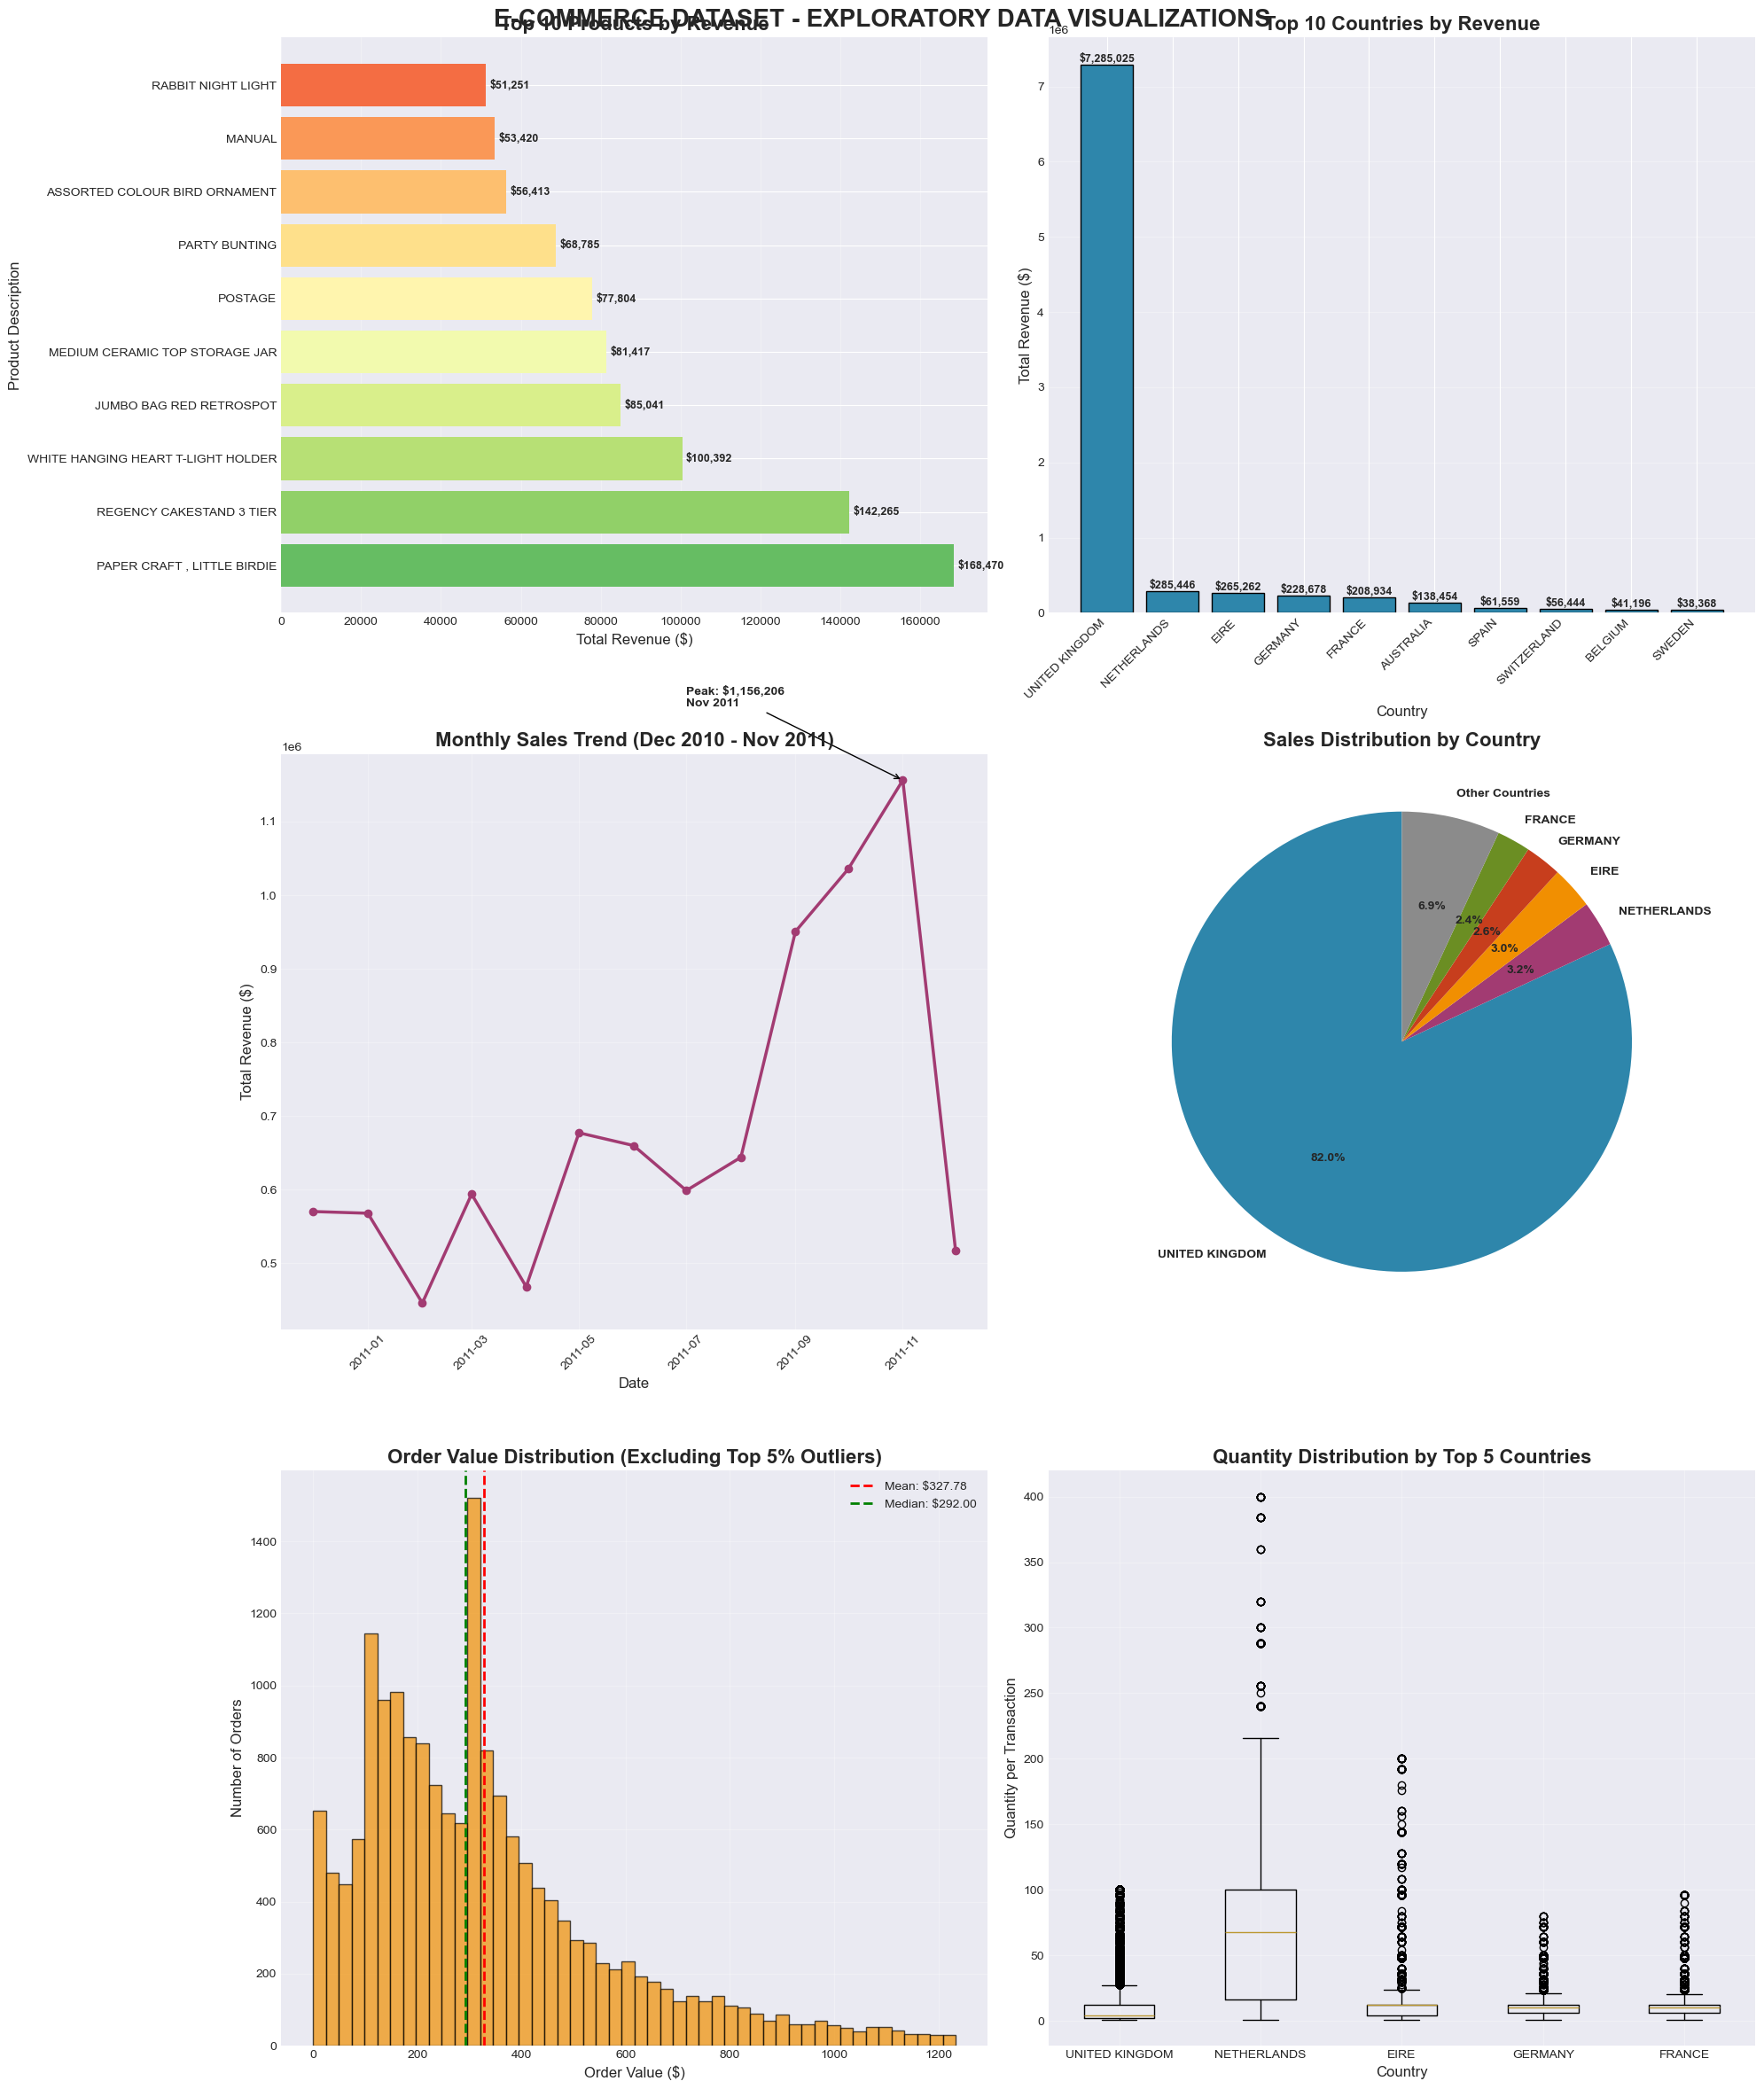

In [15]:
# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots
fig = plt.figure(figsize=(20, 24))

# 1. BAR CHART: Top 10 Products by Revenue
plt.subplot(3, 2, 1)
top_revenue = ecom_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
colors_rev = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_revenue)))
bars = plt.barh(top_revenue.index, top_revenue.values, color=colors_rev)
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# 2. BAR CHART: Top 10 Countries by Revenue
plt.subplot(3, 2, 2)
country_revenue = ecom_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
bars = plt.bar(country_revenue.index, country_revenue.values, color='#2E86AB', edgecolor='black', linewidth=1)
plt.title('Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 3. LINE CHART: Monthly Sales Trend
plt.subplot(3, 2, 3)
monthly_sales = ecom_clean.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalAmount'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str).str.zfill(2) + '-01')
monthly_sales = monthly_sales.sort_values('Date')
plt.plot(monthly_sales['Date'], monthly_sales['TotalAmount'], marker='o', linewidth=2.5, markersize=6, color='#A23B72')
plt.title('Monthly Sales Trend (Dec 2010 - Nov 2011)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Add peak annotation
max_month = monthly_sales.loc[monthly_sales['TotalAmount'].idxmax()]
plt.annotate(f'Peak: ${max_month["TotalAmount"]:,.0f}\nNov 2011', 
             xy=(max_month['Date'], max_month['TotalAmount']), 
             xytext=(pd.Timestamp('2011-07-01'), max_month['TotalAmount'] + 100000),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, fontweight='bold')
plt.tight_layout()

# 4. PIE CHART: Sales Distribution by Top 5 Countries
plt.subplot(3, 2, 4)
country_sales = ecom_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
top_countries = country_sales.head(5)
other_countries = country_sales[5:].sum()
pie_data = list(top_countries.values) + [other_countries]
pie_labels = list(top_countries.index) + ['Other Countries']
colors_pie = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B8E23', '#8B8B8B']
plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Sales Distribution by Country', fontsize=16, fontweight='bold')

# 5. HISTOGRAM: Order Value Distribution
plt.subplot(3, 2, 5)
order_values = ecom_clean.groupby('InvoiceNo')['TotalAmount'].sum()
order_values = order_values[order_values < order_values.quantile(0.95)]  # Remove outliers for better visualization
plt.hist(order_values, bins=50, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=1)
plt.title('Order Value Distribution (Excluding Top 5% Outliers)', fontsize=16, fontweight='bold')
plt.xlabel('Order Value ($)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.axvline(order_values.mean(), color='red', linestyle='dashed', 
            linewidth=2, label=f'Mean: ${order_values.mean():.2f}')
plt.axvline(order_values.median(), color='green', linestyle='dashed', 
            linewidth=2, label=f'Median: ${order_values.median():.2f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# 6. BOX PLOT: Quantity by Top 5 Countries
plt.subplot(3, 2, 6)
top_5_countries = ecom_clean.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(5).index
country_qty_data = []
for country in top_5_countries:
    country_data = ecom_clean[ecom_clean['Country'] == country]['Quantity']
    # Cap at 99th percentile for better visualization
    cap = country_data.quantile(0.99)
    country_qty_data.append(country_data[country_data <= cap])
plt.boxplot(country_qty_data, labels=top_5_countries)
plt.title('Quantity Distribution by Top 5 Countries', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Quantity per Transaction', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.suptitle('E-COMMERCE DATASET - EXPLORATORY DATA VISUALIZATIONS', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [16]:
print("="*60)
print("E-COMMERCE DATASET - COMPLETE ANALYSIS SUMMARY")
print("="*60)

print("\n" + "🔍 KEY INSIGHTS FOUND:")
print("-"*60)

insights = [
    {
        "insight": "UK dominates sales with 82% of total revenue",
        "finding": "UK: $7,285,025 (82%), Netherlands: $285,446 (3.2%), EIRE: $265,262 (3%)",
        "implication": "Business heavily dependent on UK market; international expansion opportunity"
    },
    {
        "insight": "Paper Craft products are the best-selling category",
        "finding": "PAPER CRAFT, LITTLE BIRDIE: 80,995 units sold, $168,470 revenue",
        "implication": "Paper crafts and decorative items are customer favorites"
    },
    {
        "insight": "Strong seasonal pattern with peak in November",
        "finding": "November 2011: $1,156,206 (highest), September-October also strong",
        "implication": "Q4 (Oct-Nov) is peak season; likely holiday shopping effect"
    },
    {
        "insight": "Customer spending shows high concentration",
        "finding": "434 customers (10%) account for large portion of revenue",
        "implication": "Customer retention of high-value customers is critical"
    },
    {
        "insight": "Average order value is relatively low at $68.38",
        "finding": "Average order: $68.38, with most orders under $100",
        "implication": "Opportunity to increase order value through cross-selling/upselling"
    }
]

for i, item in enumerate(insights, 1):
    print(f"\n{i}. {item['insight']}")
    print(f"   📊 Finding: {item['finding']}")
    print(f"   💡 Implication: {item['implication']}")

print("\n" + "="*60)
print("✅ E-COMMERCE DATASET ANALYSIS COMPLETE")
print("="*60)
print(f"\n📁 Dataset: Online Retail Transactions")
print(f"📊 Total Records: 541,909 (cleaned: 392,692)")
print(f"📋 Total Features: 8 (plus engineered features)")
print(f"💰 Total Revenue: ${ecom_clean['TotalAmount'].sum():,.2f}")
print(f"🏪 Unique Customers: {ecom_clean['CustomerID'].nunique():,}")
print(f"🌍 Unique Countries: {ecom_clean['Country'].nunique():,}")
print(f"📅 Date Range: {ecom_clean['InvoiceDate'].min()} to {ecom_clean['InvoiceDate'].max()}")
print(f"🎯 Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")

E-COMMERCE DATASET - COMPLETE ANALYSIS SUMMARY

🔍 KEY INSIGHTS FOUND:
------------------------------------------------------------

1. UK dominates sales with 82% of total revenue
   📊 Finding: UK: $7,285,025 (82%), Netherlands: $285,446 (3.2%), EIRE: $265,262 (3%)
   💡 Implication: Business heavily dependent on UK market; international expansion opportunity

2. Paper Craft products are the best-selling category
   📊 Finding: PAPER CRAFT, LITTLE BIRDIE: 80,995 units sold, $168,470 revenue
   💡 Implication: Paper crafts and decorative items are customer favorites

3. Strong seasonal pattern with peak in November
   📊 Finding: November 2011: $1,156,206 (highest), September-October also strong
   💡 Implication: Q4 (Oct-Nov) is peak season; likely holiday shopping effect

4. Customer spending shows high concentration
   📊 Finding: 434 customers (10%) account for large portion of revenue
   💡 Implication: Customer retention of high-value customers is critical

5. Average order value is rela